# Lindbladian Learning from  State Trajectory

This notebook contains code and visualization to test the process of Hamiltonian/Lindbladian learning from a time series of bitstring probabilities that can be obtained experimentally from a quantum device, or simulated classically.

The schematic of the process is as follows:

1. Configure the parameters of the simulation:
    The file ```config/lindbladian_learning_configuration.yaml``` contains all the parameters relevant for the simulation. It must be customized before starting the leraning process. The ```README.md``` file contains a detailed explanation of them and how to use them.

2. Load the configuration and the bitstring data. The data can be simulated with the ```generate_data.py``` script, which at the same time is configured with the ```config/data_generation_configuration.yaml```. More details on this step can be found in the ```README.md``` file

3. Parsing of the configuration file and initialization of the system

## Imports

Aside from the required packages for the program, we import all the important functions that will be needed for building the model, training the neural network, evaluating results, and plotting them. All these functions have been written in separate scripts located in the folder ```src``` to make this notebook cleaner.

In [1]:
import jax
import jax.numpy as jnp
from jax import random
from jax import tree_util as jtu
import numpy as np
import matplotlib.pyplot as plt
import copy 
import pandas as pd
import glob
import sys 
import yaml

sys.path.append('../src/')

from model_building import get_theta_shape, build_xyz_basis, build_lindblad_operators, prepare_initial_state
from diagnostics import print_training_info, print_hamiltonian_parameters, print_noise_parameters, print_relative_error, generate_diagnostic_trajectories
from mlp import init_mlp_params, mlp_forward, make_step_fn, train_phase
from figures import plot_noise_parameters, plot_hamiltonian_parameters, plot_mixed_state_fidelity, plot_purity, plot_pure_state_fidelity, plot_observables, plot_training_loss

## Loading functions

These two functions are specific to this notebook and are made to load the configuration file and data files, which have been generated previously.

In [2]:
Array = jnp.ndarray

def load_config(config_path):
    '''Load configuration from YAML file'''
    with open(config_path, 'r') as file:
        config = yaml.safe_load(file)
    return config

def load_experimental_data(config):
    """Load experimental/simulated data"""
    L = config["L"]
    T_max = config["t_max"]
    search_pattern = f"../data/experimental_data_L{L}_T{T_max:.2f}_*_config_df.csv"
    files = glob.glob(search_pattern)
    
    if not files:
        raise FileNotFoundError(f"No data found for L={L}, T={T_max:.2f}")
    
    config_file = files[0]
    file_core = config_file.replace("_config_df.csv", "").replace("../data/experimental_data_", "")
    
    print(f"\n{'='*60}")
    print(f"LOADING DATA: {file_core}")
    print(f"{'='*60}")
    
    df_counts = pd.read_csv(f"../data/experimental_data_{file_core}_counts.csv", index_col='Time')
    df_config = pd.read_csv(config_file).iloc[0]
    
    try:
        metadata = np.load(f"../data/experimental_data_{file_core}_metadata.npz")
        initial_state_vector = metadata["initial_state"]
        theta_true_array = metadata["theta_true"]
        
        # Read noise parameters from metadata
        dynamics_type = df_config["dynamics_type"] if "dynamics_type" in df_config else "schrodinger"
        noise_model = df_config.get("noise_model", "global")
        
        if dynamics_type == "lindblad":
            config["data_has_noise"] = True
            config["noise_model"] = noise_model
            
            if noise_model == "global":
                if 'T1_global' in metadata and 'T2_global' in metadata:
                    T1_true = float(metadata['T1_global'])
                    T2_true = float(metadata['T2_global'])
                    config["T1_global_true"] = T1_true
                    config["T2_global_true"] = T2_true
                    gamma_deph_true = 1.0/T2_true - 1.0/(2*T1_true)
                    gamma_damp_true = 1.0/T1_true
                    print(f"  Global noise: T1={T1_true:.2f}, T2={T2_true:.2f}")
                    print(f"  Rates: γ_deph={gamma_deph_true:.4f}, γ_damp={gamma_damp_true:.4f}")
                    config["gamma_deph_true"] = gamma_deph_true
                    config["gamma_damp_true"] = gamma_damp_true
            else:  # local noise
                if 'T1_list' in metadata and 'T2_list' in metadata:
                    T1_list_true = list(metadata['T1_list'])
                    T2_list_true = list(metadata['T2_list'])
                    config["T1_list_true"] = T1_list_true
                    config["T2_list_true"] = T2_list_true
                    
                    # Calculate rates
                    gamma_deph_list = [1.0/T2_list_true[i] - 1.0/(2*T1_list_true[i]) for i in range(L)]
                    gamma_damp_list = [1.0/T1_list_true[i] for i in range(L)]
                    config["gamma_deph_list_true"] = gamma_deph_list
                    config["gamma_damp_list_true"] = gamma_damp_list
                    
                    print(f"  Local noise - Per-qubit T1: {T1_list_true}")
                    print(f"  Local noise - Per-qubit T2: {T2_list_true}")
                    
                    # Calculate average for display
                    avg_T1 = np.mean(T1_list_true)
                    avg_T2 = np.mean(T2_list_true)
                    avg_gamma_deph = np.mean(gamma_deph_list)
                    avg_gamma_damp = np.mean(gamma_damp_list)
                    print(f"  Averages: T1={avg_T1:.2f}, T2={avg_T2:.2f}")
                    print(f"  Average rates: γ_deph={avg_gamma_deph:.4f}, γ_damp={avg_gamma_damp:.4f}")
        else:
            config["data_has_noise"] = False
            print(f"  Data generated with Schrödinger dynamics (noiseless)")
            
    except Exception as e:
        print(f"  Warning loading metadata: {e}")
        initial_state_vector = None
        theta_true_array = None
        config["data_has_noise"] = False
    
    # Update config from data
    config["N_time_shots"] = int(df_config["N_time_shots"])
    config["N_shots_per_time"] = int(df_config["N_shots_per_time"])
    
    if "hamiltonian_type" in df_config:
        data_ham_type = df_config["hamiltonian_type"]
        if config["hamiltonian_type"] != data_ham_type:
            print(f"⚠️  WARNING: Config hamiltonian_type '{config['hamiltonian_type']}' "
                  f"differs from data '{data_ham_type}'")
            config["hamiltonian_type"] = data_ham_type
    
    # Check if model matches data noise type
    use_noisy_model = config["use_noisy_dynamics"]
    data_has_noise = config.get("data_has_noise", False)
    
    if data_has_noise and not use_noisy_model:
        print(f"  ⚠️  WARNING: Data is noisy but model uses noiseless dynamics!")
    elif not data_has_noise and use_noisy_model:
        print(f"  ⚠️  WARNING: Data is noiseless but model uses noisy dynamics!")
    
    # Load true Hamiltonian parameters
    hamiltonian_type = config.get("hamiltonian_type", "uniform_xyz")
    if hamiltonian_type == "uniform_xyz" and "Jx_true" in df_config:
        config["Jx_true"] = float(df_config["Jx_true"])
        config["Jy_true"] = float(df_config["Jy_true"])
        config["Jz_true"] = float(df_config["Jz_true"])
        config["hx_true"] = float(df_config["hx_true"])
        config["hy_true"] = float(df_config["hy_true"])
        config["hz_true"] = float(df_config["hz_true"])
    elif hamiltonian_type == "general_local_zz" and theta_true_array is not None:
        L = config["L"]
        config["hx_list_true"] = list(theta_true_array[:L])
        config["hz_list_true"] = list(theta_true_array[L:2*L])
        config["Jzz_list_true"] = list(theta_true_array[2*L:])
    
    print(f"  Measurement shots: R={config['N_shots_per_time']}, J={config['N_time_shots']}")
    
    t_grid_shots = df_counts.index.values.astype(np.float32)
    counts_shots = df_counts.values.astype(np.int32)
    
    return t_grid_shots, counts_shots, initial_state_vector, theta_true_array

## Open and parse configuration file

An example file is provided here but the path can be changed in this cell if another configuration is desired

In [3]:
config_file = "../config/lindbladian_learning_configuration.yaml"

CONFIG = load_config(config_file)

t_grid_shots, counts_shots, initial_state_vector, theta_true_array = load_experimental_data(CONFIG)
L = CONFIG["L"]
dim = 2**L
hamiltonian_type = CONFIG["hamiltonian_type"]
use_noisy = CONFIG["use_noisy_dynamics"]

# Hamiltonian parameters
if hamiltonian_type == "uniform_xyz":
    theta_init_list = [CONFIG["Jx_init"], CONFIG["Jy_init"], CONFIG["Jz_init"],
                        CONFIG["hx_init"], CONFIG["hy_init"], CONFIG["hz_init"]]
elif hamiltonian_type == "general_local_zz":
    theta_init_list = (list(CONFIG["hx_list_init"]) + 
                        list(CONFIG["hz_list_init"]) + 
                        list(CONFIG["Jzz_list_init"]))
else:
    raise ValueError(f"Unknown hamiltonian_type: {hamiltonian_type}")

# Generate random keys
key = random.PRNGKey(CONFIG["seed_init"])
key, k_nn, k_th, k_noise = random.split(key, 4)


LOADING DATA: L4_T1.00_R5000_J101_schrodinger
  Data generated with Schrödinger dynamics (noiseless)
  Measurement shots: R=5000, J=101


## Initialize physical system

In [4]:
# Prepare initial state
state0 = prepare_initial_state(L, CONFIG["initial_state_kind"], 
                                initial_state_vector, 
                                as_density_matrix=use_noisy)

# Build operators
OPS_XYZ = build_xyz_basis(L, hamiltonian_type)
NUM_COEFFICIENTS = get_theta_shape(L, hamiltonian_type)

# Build Lindblad operators if needed
if use_noisy:
    dephasing_ops, damping_ops = build_lindblad_operators(L)
else:
    dephasing_ops, damping_ops = None, None

# Initial paramters
theta_init = jnp.array(theta_init_list, dtype=jnp.float32)
if CONFIG["INIT_PERTURB_SCALE"] > 0:
    theta_init += CONFIG["INIT_PERTURB_SCALE"] * random.normal(k_th, (NUM_COEFFICIENTS,))


print_training_info(CONFIG, NUM_COEFFICIENTS)


MODEL configURATION
  Dynamics: Schrödinger (noiseless)
  Hamiltonian type: uniform_xyz
  Hamiltonian parameters: 6
  Model type: white
  Learn θ: True


## Build Neural Network Architecture

In [5]:
# Initialize NN
NN_MAP_FUN = mlp_forward
NN_INPUT_DIM = 1  # Time-dependent
NN_OUTPUT_DIM = NUM_COEFFICIENTS  # NN only outputs Hamiltonian corrections

layer_sizes = [NN_INPUT_DIM] + CONFIG["NN_hidden_sizes"] + [NN_OUTPUT_DIM]
nn_params = init_mlp_params(layer_sizes, k_nn, scale=0.1)

# Create time grids
t_grid_fine = jnp.arange(0.0, CONFIG["t_max"] + CONFIG["dt"]/2, CONFIG["dt"])
T_extrap = CONFIG["t_max"] * CONFIG["T_extrapolate_factor"]
t_grid_long = jnp.arange(0.0, T_extrap + 1e-12, CONFIG["dt"])

# Training schedule
N_total = CONFIG["N_epochs"]
P1 = int(N_total * CONFIG["PHASE1_SPLIT"])
P2 = int(N_total * CONFIG["PHASE2_SPLIT"])
P3 = N_total - P1 - P2

## Combine parameters

Combines the initial parameters of the Hamiltonian ansatz and the neural network. Adititionally, it adds noise parameters if specified in the configuration

In [6]:
# Initialize noise parameters if needed
params = {"theta": theta_init, "nn": nn_params}

if use_noisy and CONFIG["learn_noise_params"]:
    if CONFIG["noise_model"] == "global":
        # Single rate for all qubits
        noise_rates_init = jnp.array([
            CONFIG["gamma_dephasing_init"],
            CONFIG["gamma_damping_init"]
        ], dtype=jnp.float32)
    else:  # local
        # Per-qubit rates
        noise_rates_init = jnp.concatenate([
            jnp.full((L,), CONFIG["gamma_dephasing_init"], dtype=jnp.float32),
            jnp.full((L,), CONFIG["gamma_damping_init"], dtype=jnp.float32)
        ])
    params["noise_rates"] = noise_rates_init
    print(f"  Initial noise rates: {noise_rates_init}")

    params["noise_rates"] = noise_rates_init

## Training Schedule

In [7]:
print(f"\n{'='*60}")
print(f"TRAINING")
print(f"{'='*60}")
print(f"  Phase 1 (Warm-up): {P1} epochs")
print(f"  Phase 2 (Distill): {P2} epochs")
print(f"  Phase 3 (Refine): {P3} epochs")

# Create step function
step_fn = make_step_fn(CONFIG, L, OPS_XYZ, NN_MAP_FUN, use_noisy,
                        dephasing_ops, damping_ops)

# Phase 1: Train everything
learn_noise_p1 = CONFIG["learn_noise_params"] if use_noisy else False
params, l1 = train_phase(params, P1, CONFIG, step_fn, t_grid_shots, state0,
                        counts_shots, train_theta=CONFIG["learn_theta"],
                        train_nn=True, train_noise=learn_noise_p1,
                        phase_name="P1 Warm-up")

# Phase 2: Distill to theta (freeze NN and noise)
params, l2 = train_phase(params, P2, CONFIG, step_fn, t_grid_shots, state0,
                        counts_shots, train_theta=CONFIG["learn_theta"],
                        train_nn=False, train_noise=False,
                        phase_name="P2 Distill")

# Phase 3: Refine NN (freeze theta, optionally train noise)
learn_noise_p3 = CONFIG["learn_noise_params"] if use_noisy else False
params, l3 = train_phase(params, P3, CONFIG, step_fn, t_grid_shots, state0,
                        counts_shots, train_theta=False,
                        train_nn=True, train_noise=learn_noise_p3,
                        phase_name="P3 Refine")

losses = l1 + l2 + l3

# Extract final parameters
theta_final = np.array(jax.device_get(params["theta"]))
nn_l2_norm = sum(jnp.sum(p**2) for p in jtu.tree_leaves(params["nn"]))


TRAINING
  Phase 1 (Warm-up): 200 epochs
  Phase 2 (Distill): 200 epochs
  Phase 3 (Refine): 100 epochs

--- Phase: P1 Warm-up ---
  θ: TRAIN, φ: TRAIN, γ: FROZEN
  [020/200] Loss: 2.6957e+00 | NLL: 2.6566e+00 | Reg_NN: 3.9115e-01 | Reg_Noise: 0.0000e+00
  [040/200] Loss: 2.6569e+00 | NLL: 2.6470e+00 | Reg_NN: 9.8914e-02 | Reg_Noise: 0.0000e+00
  [060/200] Loss: 2.6490e+00 | NLL: 2.6444e+00 | Reg_NN: 4.5706e-02 | Reg_Noise: 0.0000e+00
  [080/200] Loss: 2.6456e+00 | NLL: 2.6439e+00 | Reg_NN: 1.7917e-02 | Reg_Noise: 0.0000e+00
  [100/200] Loss: 2.6442e+00 | NLL: 2.6435e+00 | Reg_NN: 6.6105e-03 | Reg_Noise: 0.0000e+00
  [120/200] Loss: 2.6436e+00 | NLL: 2.6433e+00 | Reg_NN: 2.5658e-03 | Reg_Noise: 0.0000e+00
  [140/200] Loss: 2.6433e+00 | NLL: 2.6432e+00 | Reg_NN: 9.3834e-04 | Reg_Noise: 0.0000e+00
  [160/200] Loss: 2.6432e+00 | NLL: 2.6432e+00 | Reg_NN: 3.1661e-04 | Reg_Noise: 0.0000e+00
  [180/200] Loss: 2.6432e+00 | NLL: 2.6431e+00 | Reg_NN: 1.0390e-04 | Reg_Noise: 0.0000e+00
  [200/2

## Print summary of results

In [8]:
print(f"\n{'='*60}")
print(f"FINAL RESULTS")
print(f"{'='*60}")

print_hamiltonian_parameters(CONFIG, hamiltonian_type, theta_final, nn_l2_norm)

# Print noise parameters if learned
if "noise_rates" in params:
    print_noise_parameters(CONFIG, params)

# Compare with true parameters
if theta_true_array is not None:
    print_relative_error(theta_true_array, theta_final)
    theta_true = np.array(theta_true_array)
else:
    theta_true = None


FINAL RESULTS

Learned Hamiltonian Parameters:
  Jx        : 0.90062
  Jy        : 1.09890
  Jz        : 0.40086
  hx        : 0.29934
  hy        : 0.10107
  hz        : 0.20624

NN L2 Norm: 6.7795e-06

True Hamiltonian Parameters: [0.9 1.1 0.4 0.3 0.1 0.2]
Relative Error: 0.0035


## Plots of different quantities

### Hamiltonian parameters

[0.9 1.1 0.4 0.3 0.1 0.2]


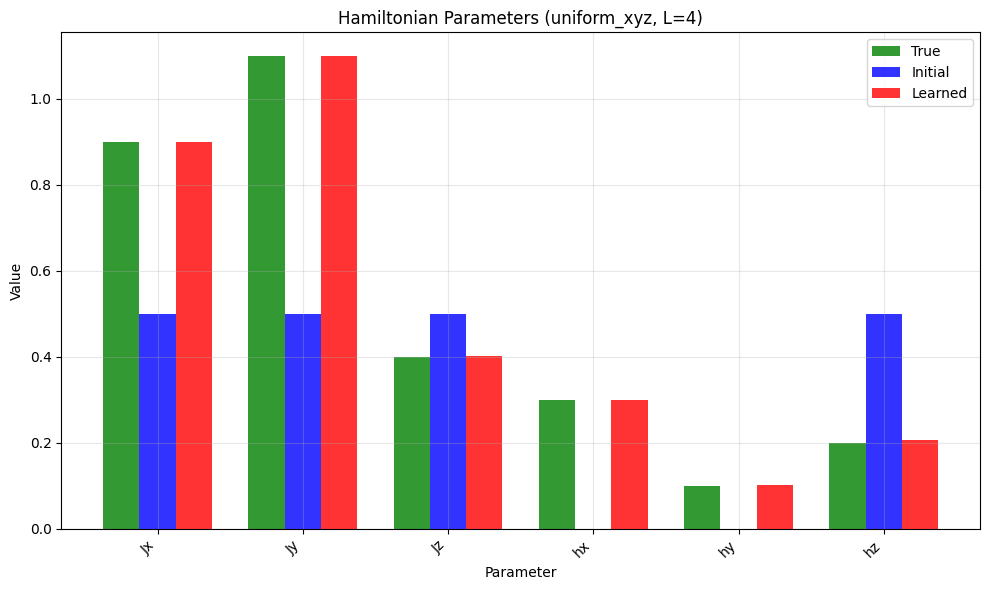

In [ ]:
fig_ham = plot_hamiltonian_parameters(theta_true, np.array(theta_init), 
                                        theta_final, hamiltonian_type, L, CONFIG)

###  Noise parameters (if applicable)

In [11]:
if "noise_rates" in params:
    true_noise_rates = None
    noise_model = CONFIG.get("noise_model", "global")
    
    # Extract true rates based on noise model
    if noise_model == "global":
        if "gamma_deph_true" in CONFIG and "gamma_damp_true" in CONFIG:
            true_noise_rates = [CONFIG["gamma_deph_true"], CONFIG["gamma_damp_true"]]
    else:  # local noise model
        if "gamma_deph_list_true" in CONFIG and "gamma_damp_list_true" in CONFIG:
            # Concatenate dephasing rates first, then damping rates
            true_noise_rates = np.concatenate([
                np.array(CONFIG["gamma_deph_list_true"]),
                np.array(CONFIG["gamma_damp_list_true"])
            ])
    
    # Learned noise rates (convert to numpy)
    try:
        learned_noise_rates = np.array(jax.device_get(params["noise_rates"]))
    except Exception as e:
        print(f"  Warning: failed to get learned noise rates: {e}")
        learned_noise_rates = None
    
    # Plot noise parameters
    if learned_noise_rates is not None:
        try:
            fig_noise = plot_noise_parameters(learned_noise_rates, true_noise_rates, noise_model, L, CONFIG)
            #plt.show()
        except Exception as e:
            print(f"  Warning: failed to plot noise parameters: {e}")
    else:
        print("  Warning: No learned noise rates to plot")

### Fidelity

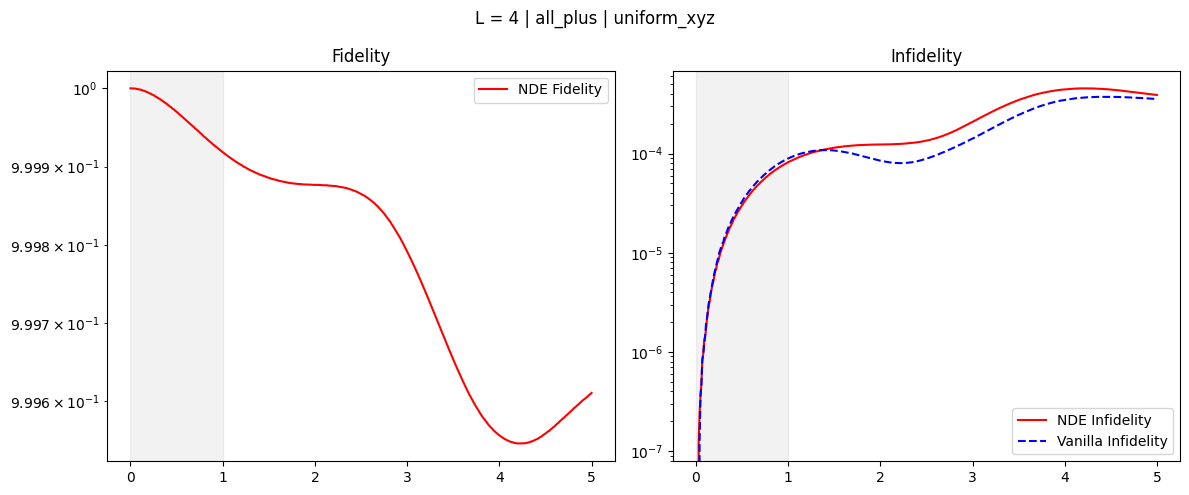

In [ ]:
# Generate trajectories of the learned and original models
traj_model, traj_vanilla, traj_true, obs_true, obs_model, obs_vanilla = generate_diagnostic_trajectories(CONFIG, OPS_XYZ, NN_MAP_FUN, 
                                                                                                        dephasing_ops, damping_ops, 
                                                                                                        state0, t_grid_long, params, theta_true)

if use_noisy: 
    try:
        # Mixed-state fidelity
        traj_model_np, traj_van_np = plot_mixed_state_fidelity(traj_model, traj_vanilla, traj_true, CONFIG, t_grid_long, L)
        # Purity trajectories
        plot_purity(traj_model_np, traj_van_np, t_grid_long, CONFIG)
    except Exception as e:
        print(f"  Warning: failed mixed-state diagnostics: {e}")

else:
    # Pure-state fidelity (same style as original script)
    try:
        plot_pure_state_fidelity(traj_model, traj_vanilla, traj_true, CONFIG, t_grid_long, L)
    except Exception as e:
        print(f"  Warning: failed pure-state diagnostics: {e}")

### Evolution of observables

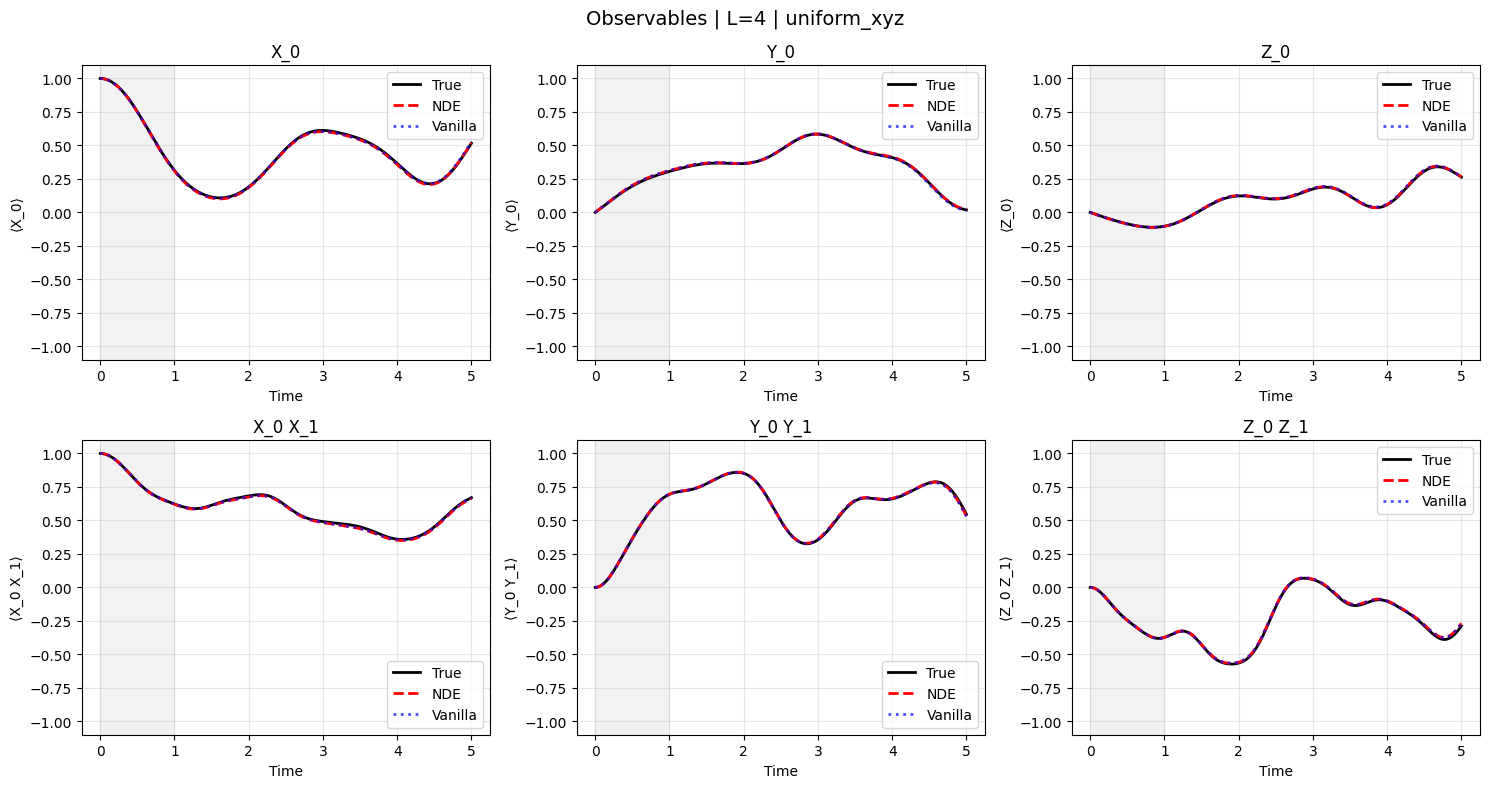

In [13]:
try:
    fig_obs = plot_observables(t_grid_long, obs_true, obs_model, obs_vanilla, L, hamiltonian_type, CONFIG)
    #plt.show()
except Exception as e:
    print(f"  Warning: failed to plot observables: {e}")

### Training loss

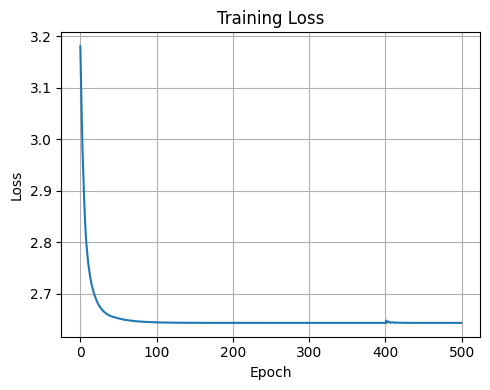

In [14]:
try:
    plot_training_loss(losses, CONFIG)
except Exception as e:
    print(f"  Warning: failed to plot training loss: {e}")